In [2]:
import numpy as np
import pandas as pd
from mplsoccer import Pitch, VerticalPitch
import matplotlib.pyplot as plt
from matplotlib import animation

In [3]:
# Load Full Tracking Data
tracking_df = pd.read_json('../data/matches/1886347/1886347_tracking_extrapolated.jsonl', lines=True)
raw_df =pd.json_normalize(tracking_df.to_dict('records'), 'player_data',
                         ['frame','timestamp','period','possession','ball_data'])

# Clean Tracking Data
raw_df['possession_player_id'] = raw_df['possession'].apply(lambda x: x.get('player_id'))
raw_df['possession_group'] = raw_df['possession'].apply(lambda x: x.get('group'))
raw_df[['ball_x','ball_y','ball_z','is_detected_ball']]=pd.json_normalize(raw_df.ball_data)
raw_df = raw_df.drop(columns=['possession','ball_data'])
raw_df.head()

,x,y,player_id,is_detected,frame,timestamp,period,possession_player_id,possession_group,ball_x,ball_y,ball_z,is_detected_ball
0,-39.63,-0.08,51009,False,10,2026-03-31,1.0,NaN,None,0.32,0.38,0.13,True
1,-19.21,-9.18,176224,True,10,2026-03-31,1.0,NaN,None,0.32,0.38,0.13,True
2,-21.83,0.47,51649,True,10,2026-03-31,1.0,NaN,None,0.32,0.38,0.13,True
3,-1.16,-32.47,50983,True,10,2026-03-31,1.0,NaN,None,0.32,0.38,0.13,True
4,-18.88,15.73,735578,True,10,2026-03-31,1.0,NaN,None,0.32,0.38,0.13,True


In [4]:
# convert timestamp to seconds
raw_df["timestamp"] = list(map(lambda x: x.hour * 3600 + x.minute * 60 + x.second, raw_df["timestamp"]))

In [5]:
print(raw_df["timestamp"].describe())

count    956076.000000
mean       2686.454232
std        1655.736591
min           0.000000
25%        1258.000000
50%        2634.000000
75%        4055.000000
max        5823.000000
Name: timestamp, dtype: float64


In [6]:
raw_df.head()

,x,y,player_id,is_detected,frame,timestamp,period,possession_player_id,possession_group,ball_x,ball_y,ball_z,is_detected_ball
0,-39.63,-0.08,51009,False,10,0,1.0,NaN,None,0.32,0.38,0.13,True
1,-19.21,-9.18,176224,True,10,0,1.0,NaN,None,0.32,0.38,0.13,True
2,-21.83,0.47,51649,True,10,0,1.0,NaN,None,0.32,0.38,0.13,True
3,-1.16,-32.47,50983,True,10,0,1.0,NaN,None,0.32,0.38,0.13,True
4,-18.88,15.73,735578,True,10,0,1.0,NaN,None,0.32,0.38,0.13,True


In [7]:
print(raw_df[raw_df["frame"]==3125])

           x      y  player_id  is_detected frame  timestamp period  \
65758 -34.75  -6.15      51009        False  3125        311    1.0   
65759  -2.54 -29.26     176224        False  3125        311    1.0   
65760  -7.26 -15.47      51649        False  3125        311    1.0   
65761  13.17 -29.27      50983        False  3125        311    1.0   
65762  -3.59  -2.61     735578        False  3125        311    1.0   
65763  10.08 -23.97      50978        False  3125        311    1.0   
65764   3.59 -19.32     735574        False  3125        311    1.0   
65765  20.28  -9.43     795507        False  3125        311    1.0   
65766  21.51 -30.14     795505        False  3125        311    1.0   
65767  12.05   1.90     735573        False  3125        311    1.0   
65768  20.46 -19.35     966120        False  3125        311    1.0   
65769  43.61  -2.87     285188        False  3125        311    1.0   
65770  18.96 -10.61      51667        False  3125        311    1.0   
65771 

In [8]:
# load dynamic data for team names
dynamic_df_full = pd.read_csv('../data/matches/1886347/1886347_dynamic_events.csv')
        
dynamic_df = dynamic_df_full[["player_id", "team_id"]].drop_duplicates().reset_index().drop(columns=["index"])

In [9]:
print(dynamic_df)

    player_id  team_id
0      966120     1805
1       51649     1805
2      735574     1805
3      735578     1805
4       50951     4177
5       50978     1805
6      795507     1805
7      735573     1805
8       38673     4177
9       33697     4177
10     133498     4177
11     965685     4177
12     795505     1805
13      23418     4177
14      50983     1805
15      51009     1805
16     176224     1805
17     133501     4177
18      51713     4177
19      14736     4177
20      51667     4177
21     285188     4177
22     560992     1805
23     795506     1805
24      43829     4177
25     163972     4177
26     797297     1805
27     800320     1805
28      31147     4177


In [10]:
full_df = raw_df.merge(dynamic_df, left_on="player_id", right_on="player_id")
full_df.head()

,x,y,player_id,is_detected,frame,timestamp,period,possession_player_id,possession_group,ball_x,ball_y,ball_z,is_detected_ball,team_id
0,-39.63,-0.08,51009,False,10,0,1.0,NaN,None,0.32,0.38,0.13,True,1805
1,-19.21,-9.18,176224,True,10,0,1.0,NaN,None,0.32,0.38,0.13,True,1805
2,-21.83,0.47,51649,True,10,0,1.0,NaN,None,0.32,0.38,0.13,True,1805
3,-1.16,-32.47,50983,True,10,0,1.0,NaN,None,0.32,0.38,0.13,True,1805
4,-18.88,15.73,735578,True,10,0,1.0,NaN,None,0.32,0.38,0.13,True,1805


In [11]:
# want the home team to be one
full_df["team_id"] = list(map(lambda test: 1 if test==1805 else 0, full_df["team_id"]))

In [12]:
full_df.head()

,x,y,player_id,is_detected,frame,timestamp,period,possession_player_id,possession_group,ball_x,ball_y,ball_z,is_detected_ball,team_id
0,-39.63,-0.08,51009,False,10,0,1.0,NaN,None,0.32,0.38,0.13,True,1
1,-19.21,-9.18,176224,True,10,0,1.0,NaN,None,0.32,0.38,0.13,True,1
2,-21.83,0.47,51649,True,10,0,1.0,NaN,None,0.32,0.38,0.13,True,1
3,-1.16,-32.47,50983,True,10,0,1.0,NaN,None,0.32,0.38,0.13,True,1
4,-18.88,15.73,735578,True,10,0,1.0,NaN,None,0.32,0.38,0.13,True,1


In [13]:
# drop columns not necessary for home and away player locations
drop = ["ball_x", "ball_y", "ball_z", "is_detected_ball"] 
df_away = full_df[full_df["team_id"]==0].drop(columns=drop)
df_home = full_df[full_df["team_id"]==1].drop(columns=drop)

In [14]:
print(df_away.head())
print(df_home.head())

        x      y  player_id  is_detected frame  timestamp period  \
11  40.47   0.24     285188        False    10          0    1.0   
12  17.85   5.52      51667         True    10          0    1.0   
13  16.78  -3.67      33697         True    10          0    1.0   
14  17.03  14.69      51713         True    10          0    1.0   
15  17.55 -13.60     133498         True    10          0    1.0   

    possession_player_id possession_group  team_id  
11                   NaN             None        0  
12                   NaN             None        0  
13                   NaN             None        0  
14                   NaN             None        0  
15                   NaN             None        0  
       x      y  player_id  is_detected frame  timestamp period  \
0 -39.63  -0.08      51009        False    10          0    1.0   
1 -19.21  -9.18     176224         True    10          0    1.0   
2 -21.83   0.47      51649         True    10          0    1.0   
3  -1

In [15]:
# drop columns not necessary for ball location
drop_ball = ["x", "y", "player_id", "is_detected", "possession_player_id", "possession_group", "team_id"]
df_ball = full_df.drop(columns=drop_ball).drop_duplicates().reset_index().drop(columns="index")

In [16]:
df_ball.head()

,frame,timestamp,period,ball_x,ball_y,ball_z,is_detected_ball
0,10,0,1.0,0.32,0.38,0.13,True
1,11,0,1.0,0.54,0.08,0.22,True
2,12,0,1.0,0.57,-0.07,0.19,True
3,13,0,1.0,0.56,-0.07,0.14,True
4,14,0,1.0,0.59,-0.03,0.14,True


In [17]:
df_ball_test = df_ball.iloc[100:225]
frames = list(df_ball_test["frame"])
print(frames)

[110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234]


In [18]:
df_home_test = []
df_away_test = []
for frame in frames:
    df_home_test.append(df_home[df_home["frame"]==frame])
    df_away_test.append(df_away[df_away["frame"]==frame])
df_home_test = pd.concat(df_home_test, ignore_index=True)
df_away_test = pd.concat(df_away_test, ignore_index=True)

In [19]:
df_home_test.head()

,x,y,player_id,is_detected,frame,timestamp,period,possession_player_id,possession_group,team_id
0,-39.73,3.98,51009,False,110,10,1.0,966120.0,away team,1
1,-13.64,-1.21,176224,True,110,10,1.0,966120.0,away team,1
2,-17.11,12.15,51649,True,110,10,1.0,966120.0,away team,1
3,11.65,-23.18,50983,True,110,10,1.0,966120.0,away team,1
4,-5.19,26.16,735578,True,110,10,1.0,966120.0,away team,1


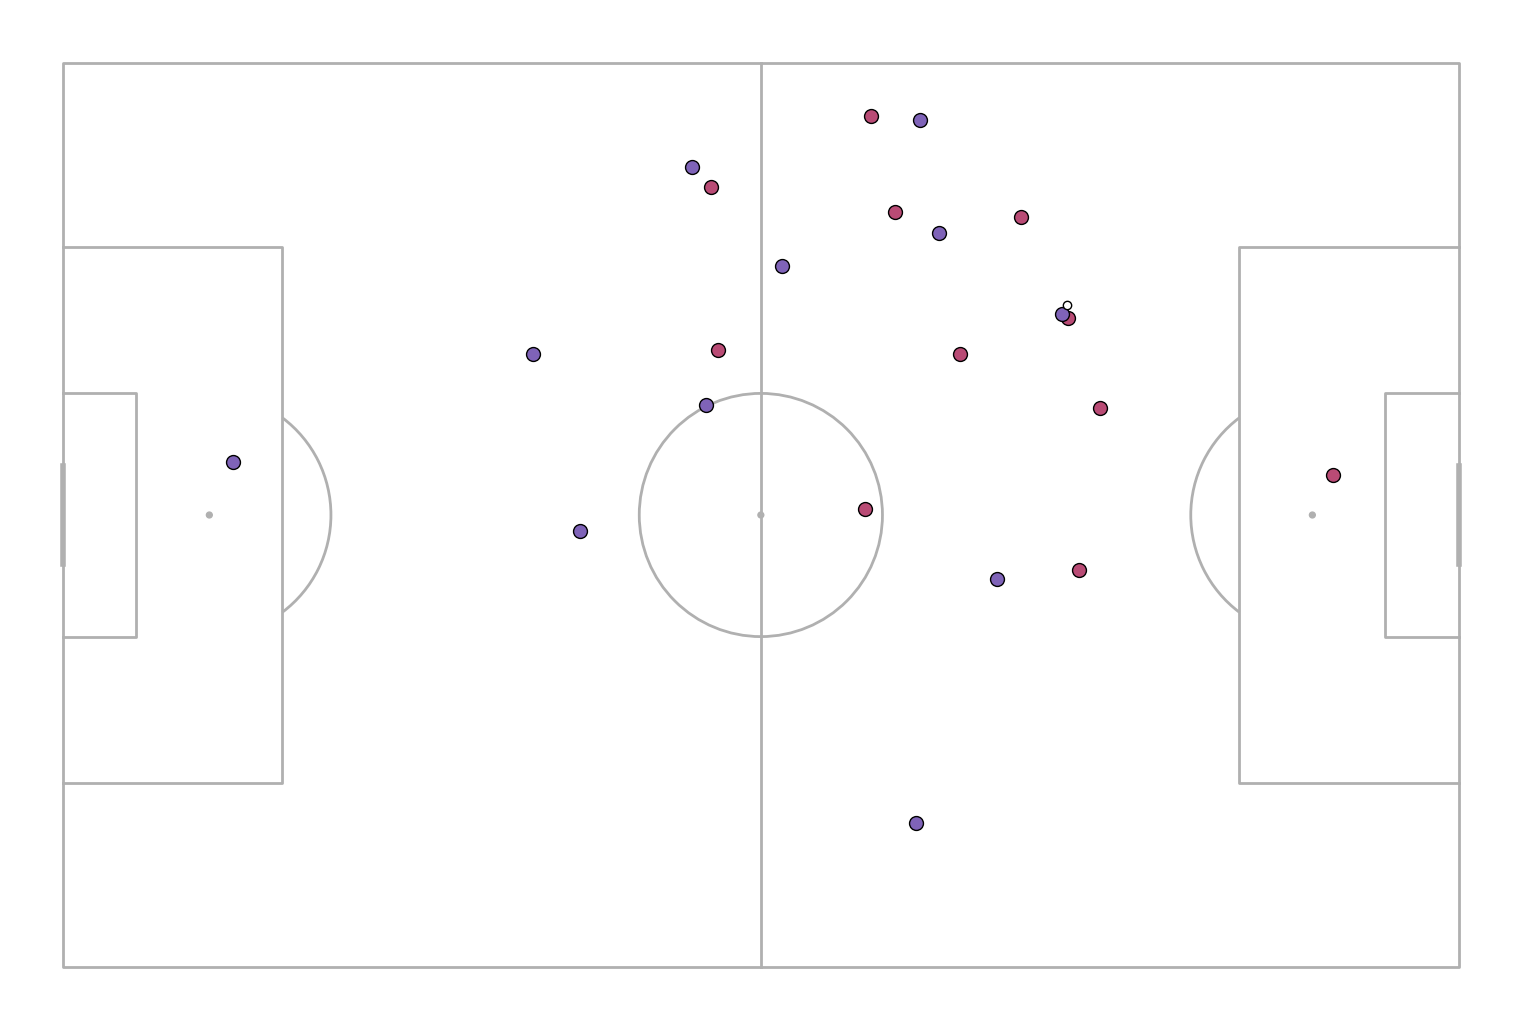

In [ ]:
# First set up the figure, the axis
pitch = Pitch(pitch_type="skillcorner", pitch_length=105, pitch_width=68)
fig, ax = pitch.draw(figsize=(16, 10.4))

# then setup the pitch plot markers we want to animate
marker_kwargs = {'marker': 'o', 'markeredgecolor': 'black', 'linestyle': 'None'}
ball, = ax.plot([], [], ms=6, markerfacecolor='w', zorder=3, **marker_kwargs)
away, = ax.plot([], [], ms=10, markerfacecolor='#b94b75', **marker_kwargs)  # red/maroon
home, = ax.plot([], [], ms=10, markerfacecolor='#7f63b8', **marker_kwargs)  # purple


# animation function
def animate(i):
    """ Function to animate the data. Each frame it sets the data for the players and the ball."""
    # set the ball data with the x and y positions for the ith frame
    ball.set_data(df_ball_test.iloc[i, [3]], df_ball_test.iloc[i, [4]])
    # get the frame id for the ith frame
    frame = df_ball_test.iloc[i, 0]
    # set the player data using the frame id
    x_away = df_away_test.loc[df_away_test["frame"]==frame, 'x']
    y_away = df_away_test.loc[df_away_test["frame"]==frame, 'y']
    x_home = df_home_test.loc[df_home_test["frame"]==frame, 'x']
    y_home = df_home_test.loc[df_home_test["frame"]==frame, 'y']
    away.set_data(x_away, y_away)
    home.set_data(x_home, y_home)

    return ball, away, home

# call the animator, animate so 25 frames per second
anim = animation.FuncAnimation(fig, animate, frames=len(df_ball_test), interval=500, blit=True)
plt.show()
anim.save('example.gif', dpi=150, fps=25, savefig_kwargs={'pad_inches':0, 'facecolor':'#457E29'}, writer="pillow")